# Introdução
O presente notebook aplica o processo de tratamento (explicado em exemploMatricula.ipynb) aos datasets de matrículas dos anos de 2013 à 2022.
Originalmente, os arquivos CSV referentes aos datasets de cada período acadêmico não tinham padrão de nomeamento bem definidos, como visto na imagem abaixo. 

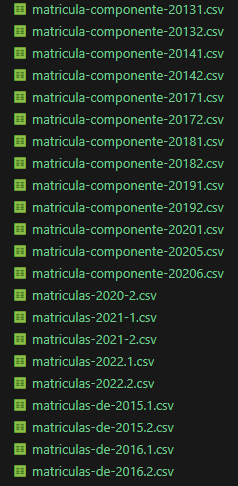

A incosistência no padrão de nomeamento atrapalha na automação do tratamento para os diferentes arquivos CSV, tendo isso em mente os nomes dos arquivos foram alterados para seguir o padrão do ano mais recente abordado pelos datasets (2022). Então o novo padrão é "matriculas-$ano$.$periodo$.csv", onde $ano$ e $periodo$ são números. Dessa forma, os arquivos ficaram organizados como mostra a imagem abaixo.

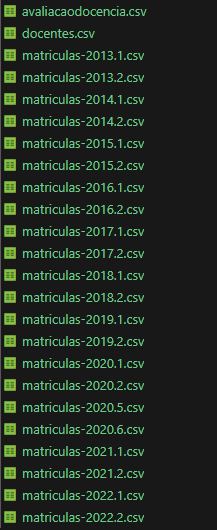

# Preparando o ambiente

Importando bibliotecas

In [13]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [14]:
pd.set_option('future.no_silent_downcasting', True)

def processar_matriculas(ano, periodo):
    # Configurações iniciais
    caminho_entrada = Path(f"../matriculas_discentes/matriculas-{ano}.{periodo}.csv")
    caminho_saida = Path(f"../turmas_agrupado/matriculas-{ano}.{periodo}_agrupado.csv")
    categorias_descricao = [
        'APROVADO', 'DESISTENCIA', 'REPROVADO POR MÉDIA E POR FALTAS',
        'TRANCADO', 'APROVADO POR NOTA', 'REPROVADO',
        'REPROVADO POR FALTAS', 'REPROVADO POR NOTA E FALTA',
        'REPROVADO POR NOTA'
    ]
    
    try:
        # Ler o arquivo original
        df = pd.read_csv(caminho_entrada, sep=';', dtype={'id_turma': str, 'id_curso': str})

        # Primeiro filtro - Remover categorias indesejadas
        valores_indesejados = ['INDEFERIDO', 'EXCLUIDA', 'CUMPRIU', 'DISPENSADO',
                             'EM ESPERA', 'AGUARDANDO DEFERIMENTO', 'MATRICULADO', 'CANCELADO']
        df_filtrado = df[~df['descricao'].isin(valores_indesejados)].copy()

        # Segundo filtro - Remover unidade nula + aprovados
        mascara = ~((df_filtrado['unidade'].isna()) & (df_filtrado['descricao'] == 'APROVADO'))
        df_filtrado = df_filtrado[mascara]

        # Terceiro filtro - Remover turmas com média nula e aprovados
        turmas_problematicas = df_filtrado[
            (df_filtrado['media_final'].isna()) & 
            (df_filtrado['descricao'] == 'APROVADO')
        ]['id_turma'].unique()
        
        df_filtrado = df_filtrado[~df_filtrado['id_turma'].isin(turmas_problematicas)]

        # Quarto filtro - Remover duplicatas
        df_filtrado = df_filtrado.drop_duplicates(subset=['id_turma', 'discente'], keep='first')

        # Converter media_final para float
        def converter_media(valor):
            try:
                if pd.isna(valor): return np.nan
                return float(str(valor).replace(',', '.'))
            except: return np.nan
            
        df_filtrado.loc[:, 'media_final'] = df_filtrado['media_final'].apply(converter_media)

        # Agrupar dados (INCLUINDO id_curso)
        # 1. Filtra apenas os alunos para o cálculo da média
        alunos_para_media = df_filtrado[
            df_filtrado['descricao'].isin(['APROVADO', 'APROVADO POR NOTA', 'REPROVADO POR NOTA'])
        ]

        # 2. Calcula a média apenas desses alunos (agrupando por id_turma e id_curso)
        media_filtrada = alunos_para_media.groupby(['id_turma', 'id_curso'])['media_final'].mean().rename('media_final_geral')

        # 3. Agregações gerais (com TODOS os alunos)
        df_agrupado = df_filtrado.groupby(['id_turma', 'id_curso']).agg(
            total_alunos=('discente', 'count')
        )

        # 4. Combina os resultados
        df_agrupado = df_agrupado.join(media_filtrada, how='left')

        # 5. Preenche turmas sem alunos nas categorias específicas
        df_agrupado['media_final_geral'] = df_agrupado['media_final_geral'].fillna(0)

        # Adicionar contagem por categoria
        for categoria in categorias_descricao:
            col_name = f'qtd_{categoria.lower().replace(" ", "_")}'
            temp_df = (
                df_filtrado[df_filtrado['descricao'] == categoria]
                .groupby(['id_turma', 'id_curso'])
                .size()
                .rename(col_name)
            )
            df_agrupado = df_agrupado.join(temp_df, how='left')

        # Tratar valores nulos e tipos
        df_agrupado = df_agrupado.fillna(0).astype(
            {col: int for col in df_agrupado.columns if col.startswith('qtd_')}
        )

        # Reset index para transformar id_turma e id_curso em colunas
        df_agrupado = df_agrupado.reset_index()

        # Adicionar colunas de ano e período
        df_agrupado['ano'] = ano
        df_agrupado['periodo'] = periodo

        # Criar coluna total_aprovados (qtd_aprovado + qtd_aprovado_por_nota)
        df_agrupado['total_aprovados'] = (
            df_agrupado['qtd_aprovado'] + 
            df_agrupado['qtd_aprovado_por_nota']
        )

        # Reordenar colunas conforme solicitado
        colunas_ordenadas = [
            'id_turma',
            'id_curso',
            'ano',
            'periodo',
            'media_final_geral',
            'total_alunos',
            'qtd_aprovado',
            'qtd_aprovado_por_nota',
            'total_aprovados',
            'qtd_reprovado',
            'qtd_reprovado_por_média_e_por_faltas',
            'qtd_reprovado_por_faltas',
            'qtd_reprovado_por_nota_e_falta',
            'qtd_reprovado_por_nota',
            'qtd_desistencia',
            'qtd_trancado'
        ]
        
        df_agrupado = df_agrupado[colunas_ordenadas]

        # Salvar resultado
        os.makedirs(caminho_saida.parent, exist_ok=True)
        df_agrupado.to_csv(caminho_saida, sep=';', index=False, encoding='utf-8')
        print(f"Arquivo {caminho_saida.name} gerado com sucesso!")

    except Exception as e:
        print(f"Erro ao processar {ano}.{periodo}: {str(e)}")

In [15]:
# Processar todos os anos e períodos
for ano in range(2013, 2025):
    # Definir períodos por ano
    periodos = [1, 2]
    if ano == 2020:
        periodos = [1, 2, 5, 6]  # Períodos especiais para 2020
    
    for periodo in periodos:
        processar_matriculas(ano, periodo)

print("Processamento concluído para todos os arquivos!")

Arquivo matriculas-2013.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2013.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2014.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2014.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2015.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2015.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2016.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2016.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2017.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2017.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2018.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2018.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2019.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2019.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2020.1_agrupado.csv gerado com sucesso!
Arquivo matriculas-2020.2_agrupado.csv gerado com sucesso!
Arquivo matriculas-2020.5_agrupado.csv gerado com sucess

Agora vamos juntar todos os .csv gerados num só

In [16]:
def consolidar_turmas_geral():
    # Configurações
    dir_entrada = Path("../turmas_agrupado")
    arquivo_saida = Path("../databases/turmas_geral.csv")
    padrao_arquivo = "matriculas-*_agrupado.csv"
    
    # Lista todos os arquivos que seguem o padrão
    arquivos = list(dir_entrada.glob(padrao_arquivo))
    
    if not arquivos:
        print("Nenhum arquivo encontrado para consolidar.")
        return
    
    # Lista para armazenar os DataFrames
    dfs = []
    
    for arquivo in arquivos:
        try:
            # Carrega o arquivo
            df = pd.read_csv(arquivo, sep=';', dtype={'id_turma': str, 'id_curso': str})
            
            dfs.append(df)
            
            print(f"Processado: {arquivo.name}")
            
        except Exception as e:
            print(f"Erro ao processar {arquivo.name}: {str(e)}")
            continue
    
    if not dfs:
        print("Nenhum DataFrame válido para consolidar.")
        return
    
    # Concatena todos os DataFrames
    df_consolidado = pd.concat(dfs, ignore_index=True)
    
    # Ordena por ano, período, curso e turma
    df_consolidado.sort_values(['ano', 'periodo', 'id_curso', 'id_turma'], inplace=True)
    
    # Garantir a ordem das colunas
    colunas_finais = [
        'id_turma',
        'id_curso',
        'ano',
        'periodo',
        'media_final_geral',
        'total_alunos',
        'qtd_aprovado',
        'qtd_aprovado_por_nota',
        'total_aprovados',
        'qtd_reprovado',
        'qtd_reprovado_por_média_e_por_faltas',
        'qtd_reprovado_por_faltas',
        'qtd_reprovado_por_nota_e_falta',
        'qtd_reprovado_por_nota',
        'qtd_desistencia',
        'qtd_trancado'
    ]
    
    df_consolidado = df_consolidado[colunas_finais]
    
    # Salva o arquivo consolidado
    arquivo_saida.parent.mkdir(parents=True, exist_ok=True)
    df_consolidado.to_csv(arquivo_saida, sep=';', index=False, encoding='utf-8')
    
    print(f"\nConsolidação concluída! Arquivo salvo em: {arquivo_saida}")
    print(f"Total de registros: {len(df_consolidado)}")
    print(f"Período abrangido: {df_consolidado['ano'].min()} a {df_consolidado['ano'].max()}")
    print(f"Total de cursos únicos: {df_consolidado['id_curso'].nunique()}")
    print(f"Total de turmas únicas: {df_consolidado['id_turma'].nunique()}")

In [17]:
consolidar_turmas_geral()

Processado: matriculas-2013.1_agrupado.csv
Processado: matriculas-2013.2_agrupado.csv
Processado: matriculas-2014.1_agrupado.csv
Processado: matriculas-2014.2_agrupado.csv
Processado: matriculas-2015.1_agrupado.csv
Processado: matriculas-2015.2_agrupado.csv
Processado: matriculas-2016.1_agrupado.csv
Processado: matriculas-2016.2_agrupado.csv
Processado: matriculas-2017.1_agrupado.csv
Processado: matriculas-2017.2_agrupado.csv
Processado: matriculas-2018.1_agrupado.csv
Processado: matriculas-2018.2_agrupado.csv
Processado: matriculas-2019.1_agrupado.csv
Processado: matriculas-2019.2_agrupado.csv
Processado: matriculas-2020.1_agrupado.csv
Processado: matriculas-2020.2_agrupado.csv
Processado: matriculas-2020.5_agrupado.csv
Processado: matriculas-2020.6_agrupado.csv
Processado: matriculas-2021.1_agrupado.csv
Processado: matriculas-2021.2_agrupado.csv
Processado: matriculas-2022.1_agrupado.csv
Processado: matriculas-2022.2_agrupado.csv
Processado: matriculas-2023.1_agrupado.csv
Processado:

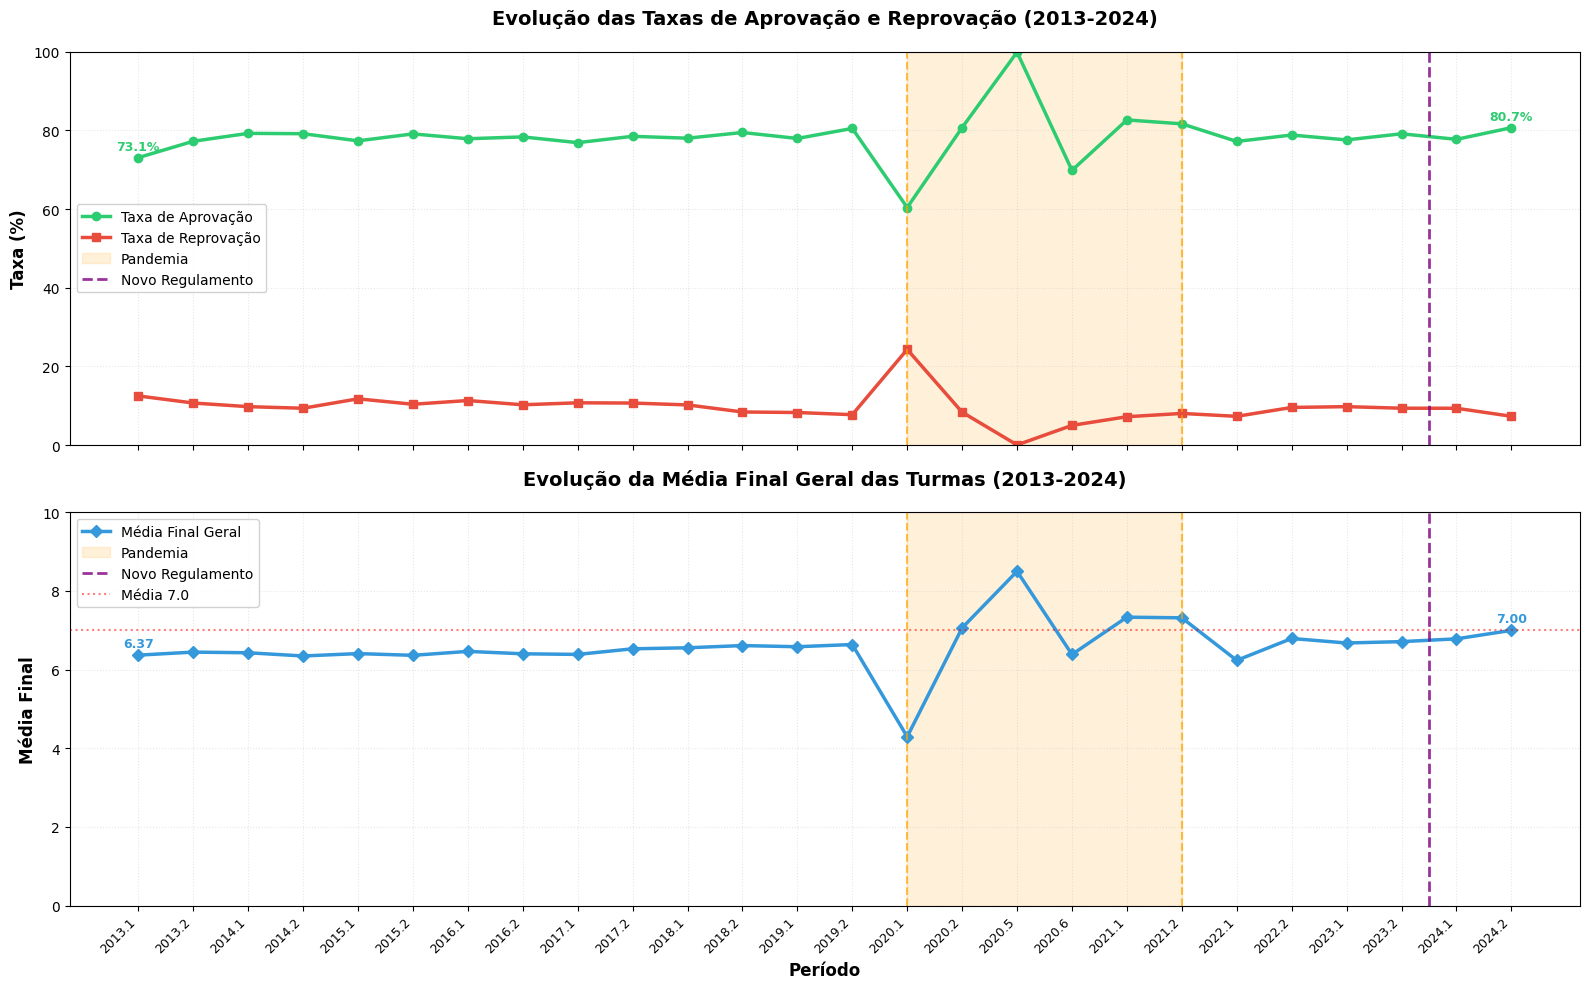

ESTATÍSTICAS RESUMIDAS

Período analisado: 2013.1 a 2024.2

Taxa de Aprovação:
  - Média geral: 78.43%
  - Maior: 99.90% (2020.5)
  - Menor: 60.40% (2020.1)

Taxa de Reprovação:
  - Média geral: 9.52%
  - Maior: 24.31% (2020.1)
  - Menor: 0.03% (2020.5)

Média Final Geral:
  - Média geral: 6.60
  - Maior: 8.50 (2020.5)
  - Menor: 4.29 (2020.1)


In [20]:
import matplotlib.pyplot as plt

df = pd.read_csv('../databases/turmas_geral.csv', sep=';')

# Criar coluna periodo_completo para o eixo x
df['periodo_completo'] = df['ano'].astype(str) + '.' + df['periodo'].astype(str)

# Agrupar por ano e período
df_agrupado = df.groupby(['ano', 'periodo', 'periodo_completo']).agg({
    'total_alunos': 'sum',
    'total_aprovados': 'sum',
    'qtd_reprovado': 'sum',
    'media_final_geral': 'mean'
}).reset_index()

# Calcular taxas
df_agrupado['taxa_aprovacao'] = (df_agrupado['total_aprovados'] / df_agrupado['total_alunos'] * 100)
df_agrupado['taxa_reprovacao'] = (df_agrupado['qtd_reprovado'] / df_agrupado['total_alunos'] * 100)

# Ordenar por ano e período
df_agrupado = df_agrupado.sort_values(['ano', 'periodo'])

# Criar figura com subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Configurar eixo x
x = np.arange(len(df_agrupado))
labels = df_agrupado['periodo_completo'].values

# ========== GRÁFICO 1: Taxas de Aprovação e Reprovação ==========
ax1.plot(x, df_agrupado['taxa_aprovacao'], marker='o', linewidth=2.5, 
         markersize=6, label='Taxa de Aprovação', color='#2ecc71')
ax1.plot(x, df_agrupado['taxa_reprovacao'], marker='s', linewidth=2.5, 
         markersize=6, label='Taxa de Reprovação', color='#e74c3c')

# Linhas tracejadas - Pandemia (2020.1 a 2021.2)
pandemia_inicio = df_agrupado[df_agrupado['periodo_completo'] == '2020.1'].index[0]
pandemia_fim = df_agrupado[df_agrupado['periodo_completo'] == '2021.2'].index[0]
ax1.axvspan(pandemia_inicio, pandemia_fim, alpha=0.15, color='orange', label='Pandemia')
ax1.axvline(x=pandemia_inicio, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.axvline(x=pandemia_fim, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)

# Linha tracejada - Novo Regulamento (entre 2023.2 e 2024.1)
novo_reg = df_agrupado[df_agrupado['periodo_completo'] == '2023.2'].index[0] + 0.5
ax1.axvline(x=novo_reg, color='purple', linestyle='--', linewidth=2, 
            alpha=0.8, label='Novo Regulamento')

ax1.set_ylabel('Taxa (%)', fontsize=12, fontweight='bold')
ax1.set_title('Evolução das Taxas de Aprovação e Reprovação (2013-2024)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax1.set_ylim([0, 100])

# Adicionar valores nas extremidades
ax1.text(0, df_agrupado.iloc[0]['taxa_aprovacao'] + 2, 
         f"{df_agrupado.iloc[0]['taxa_aprovacao']:.1f}%", 
         fontsize=9, ha='center', color='#2ecc71', fontweight='bold')
ax1.text(len(df_agrupado)-1, df_agrupado.iloc[-1]['taxa_aprovacao'] + 2, 
         f"{df_agrupado.iloc[-1]['taxa_aprovacao']:.1f}%", 
         fontsize=9, ha='center', color='#2ecc71', fontweight='bold')

# ========== GRÁFICO 2: Média Final Geral ==========
ax2.plot(x, df_agrupado['media_final_geral'], marker='D', linewidth=2.5, 
         markersize=6, label='Média Final Geral', color='#3498db')

# Linhas tracejadas - Pandemia
ax2.axvspan(pandemia_inicio, pandemia_fim, alpha=0.15, color='orange', label='Pandemia')
ax2.axvline(x=pandemia_inicio, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x=pandemia_fim, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)

# Linha tracejada - Novo Regulamento
ax2.axvline(x=novo_reg, color='purple', linestyle='--', linewidth=2, 
            alpha=0.8, label='Novo Regulamento')

# Linha de referência (média 7.0)
ax2.axhline(y=7.0, color='red', linestyle=':', linewidth=1.5, 
            alpha=0.5, label='Média 7.0')

ax2.set_xlabel('Período', fontsize=12, fontweight='bold')
ax2.set_ylabel('Média Final', fontsize=12, fontweight='bold')
ax2.set_title('Evolução da Média Final Geral das Turmas (2013-2024)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax2.set_ylim([0, 10])

# Configurar eixo x
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

# Adicionar valores nas extremidades
ax2.text(0, df_agrupado.iloc[0]['media_final_geral'] + 0.2, 
         f"{df_agrupado.iloc[0]['media_final_geral']:.2f}", 
         fontsize=9, ha='center', color='#3498db', fontweight='bold')
ax2.text(len(df_agrupado)-1, df_agrupado.iloc[-1]['media_final_geral'] + 0.2, 
         f"{df_agrupado.iloc[-1]['media_final_geral']:.2f}", 
         fontsize=9, ha='center', color='#3498db', fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

# Imprimir estatísticas resumidas
print("=" * 70)
print("ESTATÍSTICAS RESUMIDAS")
print("=" * 70)
print(f"\nPeríodo analisado: {df_agrupado.iloc[0]['periodo_completo']} a {df_agrupado.iloc[-1]['periodo_completo']}")
print(f"\nTaxa de Aprovação:")
print(f"  - Média geral: {df_agrupado['taxa_aprovacao'].mean():.2f}%")
print(f"  - Maior: {df_agrupado['taxa_aprovacao'].max():.2f}% ({df_agrupado.loc[df_agrupado['taxa_aprovacao'].idxmax(), 'periodo_completo']})")
print(f"  - Menor: {df_agrupado['taxa_aprovacao'].min():.2f}% ({df_agrupado.loc[df_agrupado['taxa_aprovacao'].idxmin(), 'periodo_completo']})")

print(f"\nTaxa de Reprovação:")
print(f"  - Média geral: {df_agrupado['taxa_reprovacao'].mean():.2f}%")
print(f"  - Maior: {df_agrupado['taxa_reprovacao'].max():.2f}% ({df_agrupado.loc[df_agrupado['taxa_reprovacao'].idxmax(), 'periodo_completo']})")
print(f"  - Menor: {df_agrupado['taxa_reprovacao'].min():.2f}% ({df_agrupado.loc[df_agrupado['taxa_reprovacao'].idxmin(), 'periodo_completo']})")

print(f"\nMédia Final Geral:")
print(f"  - Média geral: {df_agrupado['media_final_geral'].mean():.2f}")
print(f"  - Maior: {df_agrupado['media_final_geral'].max():.2f} ({df_agrupado.loc[df_agrupado['media_final_geral'].idxmax(), 'periodo_completo']})")
print(f"  - Menor: {df_agrupado['media_final_geral'].min():.2f} ({df_agrupado.loc[df_agrupado['media_final_geral'].idxmin(), 'periodo_completo']})")

In [21]:
turmas_geral = pd.read_csv('../databases/turmas_geral.csv', sep=';')

turmas_geral

,id_turma,id_curso,ano,periodo,media_final_geral,total_alunos,qtd_aprovado,qtd_aprovado_por_nota,total_aprovados,qtd_reprovado,qtd_reprovado_por_média_e_por_faltas,qtd_reprovado_por_faltas,qtd_reprovado_por_nota_e_falta,qtd_reprovado_por_nota,qtd_desistencia,qtd_trancado
0,1198765,10317040,2013,1,8.366667,27,27,0,27,0,0,0,0,0,0,0
1,1198769,10317040,2013,1,8.338462,13,13,0,13,0,0,0,0,0,0,0
2,1198772,10317040,2013,1,8.191667,12,12,0,12,0,0,0,0,0,0,0
3,1198795,10317040,2013,1,7.527273,12,11,0,11,1,0,0,0,0,0,0
4,1198826,10317040,2013,1,7.663636,11,11,0,11,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299899,57749756,96726786,2024,2,7.548387,40,31,0,31,0,9,0,0,0,0,0
299900,57749759,96726786,2024,2,9.134483,40,28,0,28,1,9,0,0,1,0,1
299901,57741299,97339504,2024,2,0.000000,4,0,0,0,0,0,3,0,0,0,1
299902,57742466,98469607,2024,2,0.000000,1,0,0,0,0,0,0,0,0,0,1
